In [3]:
!pip install --quiet pandas matplotlib seaborn wordcloud


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set styles
sns.set(style="whitegrid")


In [5]:
from google.colab import files
uploaded = files.upload()


Saving synthetic_email_dataset.csv to synthetic_email_dataset.csv


In [6]:
import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['synthetic_email_dataset.csv']))
print(df.head())


                                                text  label
0  Congratulations! You won a free lottery of the...      1
1  Congratulations! You won a free lottery of all...      1
2  Congratulations! You won a free lottery of the...      1
3  Congratulations! You won a free lottery of any...      1
4  Congratulations! You won a free lottery of $3,...      1


In [7]:
# Check for missing values
print("\nMissing values per column:\n", df.isnull().sum())

# Data types
print("\nData types:\n", df.dtypes)



Missing values per column:
 text     0
label    0
dtype: int64

Data types:
 text     object
label     int64
dtype: object


count     50.000000
mean     198.720000
std       42.027707
min       76.000000
25%      194.250000
50%      212.000000
75%      222.750000
max      253.000000
Name: length, dtype: float64


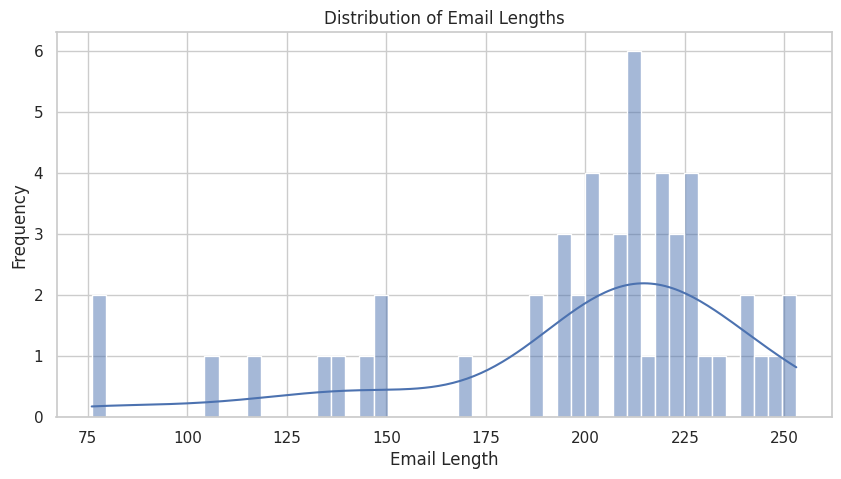

In [8]:
# Add length column
df['length'] = df['text'].apply(len)

# Basic statistics
print(df['length'].describe())

# Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['length'], bins=50, kde=True)
plt.title("Distribution of Email Lengths")
plt.xlabel("Email Length")
plt.ylabel("Frequency")
plt.show()


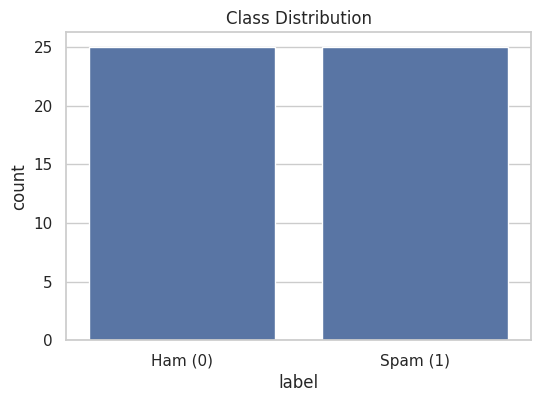

label
1    25
0    25
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['Ham (0)', 'Spam (1)'])
plt.title("Class Distribution")
plt.show()

# Print counts
print(df['label'].value_counts())


In [11]:
# Display random spam emails
print("\n--- Sample Spam Emails ---")
for i, email in enumerate(df[df['label']==1]['text'].sample(3, random_state=42), 1):
    print(f"{i}. {email}\n")

# Display random ham emails
print("\n--- Sample Ham Emails ---")
for i, email in enumerate(df[df['label']==0]['text'].sample(3, random_state=42), 1):
    print(f"{i}. {email}\n")




--- Sample Spam Emails ---
1. You have been selected for a cash prize of 1,000 rupees.


*You have already been selected for a free match

Note: Prizes will be announced via email, we will contact you if you have questions.



2. Get your free gift card now at http://giftmeals.com/tricks/tricks-tricks-1-141234013044. The offer is free.

3. Congratulations! You won a free lottery of the year and can win one for only £2,500! A special 'fan giveaway' of £50 is now open with a prize of £3,500 and it is available only at your choice of


--- Sample Ham Emails ---
1. Meeting scheduled for tomorrow at 9 am PST/12 noon EST.

We have a great crowd and we have some incredible sponsors!

2. Can we reschedule our appointment to accommodate your needs before we make the final decision?" The application is also available to anyone who was last booked. If you would like a copy of the application please click here and email us at admin@livemind

3. Dear John, I wanted to update you about my visit to 